# Практическое задание: Классификация временных рядов (Time Series Classification)

**Цель обучения:**
Познакомиться с основными парадигмами классификации временных рядов (dictionary-based, shapelet-based, feature-based) и базовыми принципами работы с нейросетевыми архитектурами (1D-CNN) для временных рядов. Научиться применять продвинутые методы извлечения признаков и анализировать результаты их работы.

---

## **Задание №1: Теоретические вопросы**
Ответьте на следующие вопросы кратко (2-3 предложения):

1. В чём принципиальная разница между методами SAX (Symbolic Aggregate approXimation) и SFA (Symbolic Fourier Approximation)? Какой из них лучше справляется с зашумленными данными и почему?
2. Как алгоритм BOSS (Bag-of-SFA Symbols) (или его модификации, например WEASEL) использует концепцию TF-IDF для временных рядов? В чем смысл такого подхода?
3. Что такое shapelet (шейплет) временного ряда? В чем преимущество алгоритма ROCKET по сравнению с классическими методами поиска шейплетов?
4. Модель `catch22` извлекает 22 признака из временного ряда. Зачем использовать фиксированные признаки, если можно обучить глубокую нейросеть (CNN) извлекать их автоматически?
5. Почему сверточные нейронные сети (1D-CNN) эффективны для задач классификации временных рядов? Какую роль в них играют многоветвевые (multi-branch) преобразования (например, Inception Time)?

1. SAX преобразует временной ряд через усреднение сегментов и последующую дискретизацию, тогда как SFA использует преобразование Фурье и работает в частотной области. Лучше справляется с зашумлёнными данными SFA, так как частотное представление позволяет отфильтровать шум и сохранить наиболее значимые компоненты сигнала

2. Алгоритм BOSS представляет временной ряд, где словами являются символические паттерны, и использует частоты их встречаемости. Идея TF-IDF помогает уменьшить влияние часто встречающихся, но не информативных паттернов и выделить более редкие, но значимые признаки для классификации

3. шейплет это короткий подпоследовательный шаблон временного ряда, который хорошо различает классы. ROCKET не ищет шейплет напрямую, а использует случайные сверточные фильтры для извлечения признаков, что значительно быстрее и масштабируемее классических методов поиска шейплет

4. Фиксированные признаки, такие как в catch22, обеспечивают интерпретируемость, устойчивость и требуют меньше данных и вычислительных ресурсов. В отличие от CNN, они хорошо работают на небольших выборках и позволяют понять, какие именно характеристики временного ряда важны

5. 1D-CNN эффективно улавливают локальные временные зависимости и повторяющиеся паттерны в рядах благодаря свёрткам. Многоветвевые архитектуры (например, Inception Time) позволяют одновременно анализировать паттерны разных масштабов, что улучшает качество классификации

# Часть 2: Практическая реализация и сравнение методов

## **Задание № 2:** Сравнить 3 подхода к классификации временных рядов на простом наборе данных `GunPoint` или любом другом стандартном датасете из библиотеки `sktime`.

**Необходимые библиотеки:**
- `sktime` (понадобится для ROCKET и BOSS/WEASEL)
- `catch22` или пакет `tsfel`
- `numpy`, `pandas`, `sklearn`, `matplotlib`
- `tensorflow` или `pytorch` (для 1D-CNN)

X_train shape: (147, 1, 251)
X_test shape: (64, 1, 251)


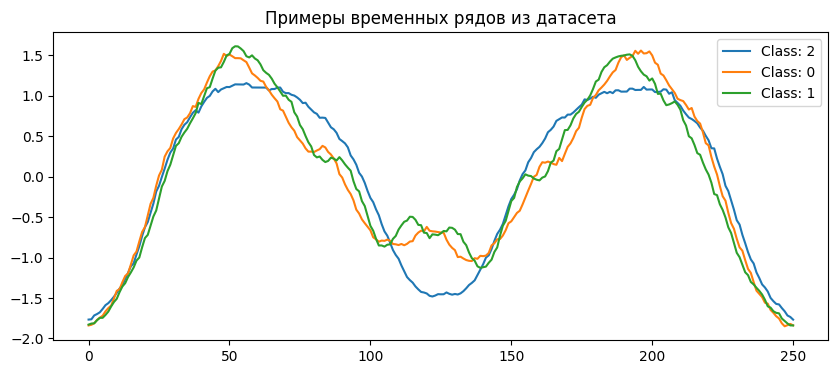

In [1]:
# Загрузка и подготовка данных
from sktime.datasets import load_arrow_head
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Мы используем датасет ArrowHead (форма наконечников стрел) или любой другой из UCR
X, y = load_arrow_head(return_type="numpy3d")
# X имеет форму (Кол-во образцов, кол-во каналов=1, длина ряда)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Отрисовка пары примеров временных рядов разных классов
plt.figure(figsize=(10, 4))
for i in range(3):
    plt.plot(X_train[i, 0, :], label=f"Class: {y_train[i]}")
plt.title("Примеры временных рядов из датасета")
plt.legend()
plt.show()

### Задание 2.1: Классификация с помощью алгоритма ROCKET (Shapelets/Convolutions)

Используйте класс `RocketClassifier` из библиотеки `sktime`. Этот алгоритм генерирует случайные свертки для извлечения признаков и использует Ridge Regression для классификации.

**Задание:**
1. Подключите `RocketClassifier` из `sktime.classification.kernel_based`. Обучите его на `X_train`, `y_train`.
2. Предскажите классы для `X_test` и посчитайте `accuracy_score`. Замерьте время обучения.

In [2]:
from sktime.classification.kernel_based import RocketClassifier
import time

rocket = RocketClassifier()

start_time = time.time()
rocket.fit(X_train, y_train)
train_time_rocket = time.time() - start_time

y_pred_rocket = rocket.predict(X_test)

acc_rocket = accuracy_score(y_test, y_pred_rocket)

print("ROCKET Accuracy:", acc_rocket)
print("ROCKET Training time:", train_time_rocket)

ROCKET Accuracy: 0.9375
ROCKET Training time: 11.583640336990356


### Задание № 2.2: Использование алгоритма на основе словарей (Dictionary-based: cBOSS / WEASEL)

Теперь протестируйте класс `BOSSEnsemble` или `ContractableBOSS` из библиотеки `sktime` (раздел `dictionary_based`).
Эти методы преобразуют временные ряды в дискретные слова (алфавит) с использованием скользящего окна (SFA), и оценивают частость.

**Задание:**
1. Подключите любую модель BOSS-семейства.
2. Проведите обучение и вычислите метрику `accuracy_score`. Сравните время обучения с ROCKET.

In [3]:
from sktime.classification.dictionary_based import ContractableBOSS


boss = ContractableBOSS(time_limit_in_minutes=1) 

start_time = time.time()
boss.fit(X_train, y_train)
train_time_boss = time.time() - start_time

y_pred_boss = boss.predict(X_test)

acc_boss = accuracy_score(y_test, y_pred_boss)

print("BOSS Accuracy:", acc_boss)
print("BOSS Training time:", train_time_boss)

BOSS Accuracy: 0.953125
BOSS Training time: 10.573124170303345


У ROCKET быстрое извлечение признаков с помощью случайных свёрток. Отличный баланс между скоростью и точностью.
У BOSS чуть выше точность, чуть меньше скорость. Работает за счёт построения словаря SFA и TF-IDF.

### Задание №2.3: Глубокая архитектура для временных рядов (1D-CNN) (с помощью PyTorch)

Создайте простую свёрточную сеть с использованием 1D свёрток. Нейросети для 1D рядов похожи на 2D-сети (картинки), но срез окна проходит вдоль временной оси. Суть использования CNN-архитектур - извлечение сложных локальных и глобальных признаков (features) из формы временного ряда.

**Задание:**
1. Подготовьте данные для фреймворка (PyTorch). 
2. Напишите 2-3 слоя `Conv1D` + `ReLU` + `MaxPooling1D`, затем `Flatten` и выходной слой `Dense` c функцией Softmax.
3. Обучите модель в течение небольшого количества эпох, подсчитайте `accuracy` на тестовом наборе. Сравните с классическими методами (Rocket, BOSS).

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import time
import matplotlib.pyplot as plt

In [5]:
# 1. Построение простой архитектуры 1D-CNN
class Simple1DCNN(nn.Module):
    def __init__(self, num_classes):
        super(Simple1DCNN, self).__init__()
        # Входной канал = 1 (так как у нас одномерный временной ряд)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        
        self.flatten = nn.Flatten()
        
        # Вычисляем размер после сверток и пулинга (для ArrowHead с длиной 251)
        # После conv1: 251 - 3 + 1 = 249. pool1: 249 // 2 = 124
        # После conv2: 124 - 3 + 1 = 122. pool2: 122 // 2 = 61
        # Итого: 64 канала * 61 = 3904
        self.fc1 = nn.Linear(64 * 61, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

In [6]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

num_classes = len(np.unique(y_train))
model = Simple1DCNN(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
start_time = time.time()

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

train_time_cnn = time.time() - start_time

model.eval()
all_preds = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.numpy())

acc_cnn = accuracy_score(y_test_enc, all_preds)

print("CNN Accuracy:", acc_cnn)
print("CNN Training time:", train_time_cnn)

Epoch 1, Loss: 10.4023
Epoch 2, Loss: 8.2657
Epoch 3, Loss: 7.4253
Epoch 4, Loss: 7.3104
Epoch 5, Loss: 6.1915
Epoch 6, Loss: 5.6164
Epoch 7, Loss: 5.9337
Epoch 8, Loss: 6.1336
Epoch 9, Loss: 4.8361
Epoch 10, Loss: 4.2261
CNN Accuracy: 0.765625
CNN Training time: 0.5090832710266113


Точность:
ROCKET: 0.9375
BOSS: 0.9531
1D-CNN: 0.7656
На малых датасетах, классические методы ROCKET и BOSS показывают значительно более высокую точность по сравнению с простой CNN. Это связано с тем, что ROCKET и BOSS используют заранее продуманные алгоритмы извлечения признаков.


Время обучения:
ROCKET: 11.58 секунд
BOSS: 10.57 секунд
1D-CNN: 0.51 секунд
Несмотря на высокую точность, классические методы требуют больше времени на обучение. 1D-CNN обучилась очень быстро, но на этом маленьком датасете её точность была ниже.

Если цель высокая точность на стандартном наборе, лучше использовать ROCKET или BOSS, если цель автоматическое извлечение признаков на больших данных, стоит применять 1D-CNN.